In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel,Field
from typing import List,Annotated
import operator

load_dotenv()
import os


In [12]:
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview",api_key=os.getenv('GEMINI_API_KEY'))

In [13]:
class EvaluationSchema(BaseModel):
    feedback : str =Field(description='detail feedback for the eassy')
    score : int = Field(description='score out of 10',ge=0,le=10)
    

In [14]:
structure_model = llm.with_structured_output(EvaluationSchema)
essay = os.getenv("EASSY")
print(essay)


"Artificial Intelligence (AI) is transforming the world, and India is emerging as a key player in this technological revolution. With its vast population, growing digital infrastructure, and strong IT sector, India is uniquely positioned to leverage AI for economic growth and social development.


In [15]:
prompt = f"""
"""

# res = structure_model.invoke(prompt)

# print(res.score)

In [ ]:
class UPSCState(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_score : Annotated[list[int],operator.add]
    average_score : float

In [ ]:
def el(state:UPSCState):
    prompt = f"Evaluate the language quality of the following eassy and provide a feedback and assign score out of 10 \neassy:\n{state['essay']}"
    output = structure_model.invoke(prompt)
    return {'language_feedback':output.feedback,"individual_score":[output.score]}

def ea(state:UPSCState):
    prompt = f"Evaluate the depth of analysis  of the following eassy and provide a feedback and assign score out of 10 \neassy:\n{state['essay']}"
    output = structure_model.invoke(prompt)
    return {'analysis_feedback':output.feedback,"individual_score":[output.score]}

def et(state:UPSCState):
    prompt = f"Evaluate the clarity of thought  of the following eassy and provide a feedback and assign score out of 10 \neassy:\n{state['essay']}"
    output = structure_model.invoke(prompt)
    return {'clarity_feedback':output.feedback,"individual_score":[output.score]}

def fe(state:UPSCState):

    prompt = f"based on the following feedback create summarize feedback \n language_feedback - {state['language_feedback']} \n analysis_feedback - {state['analysis_feedback']} \n clarity_feedback - {state['clarity_feedback']}"
    res = llm.invoke(prompt)
    
    average_score = round(sum(state['individual_score'])/len(state['individual_score']),2)

    return {'overall_feedback':res.content[0]['text'],'average_score':average_score}






In [18]:
graph = StateGraph(UPSCState)

graph.add_node('el',el)
graph.add_node('ea',ea)
graph.add_node('et',et)
graph.add_node('fe',fe)


graph.add_edge(START,'el')
graph.add_edge(START,'ea')
graph.add_edge(START,'et')

graph.add_edge('el','fe')
graph.add_edge('ea','fe')
graph.add_edge('et','fe')

graph.add_edge('fe',END)

workflow = graph.compile()

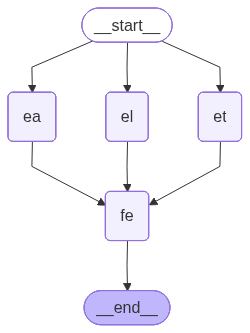

In [19]:
workflow

In [20]:
intial_state = {'essay':essay}

workflow.invoke(intial_state)

{'essay': '"Artificial Intelligence (AI) is transforming the world, and India is emerging as a key player in this technological revolution. With its vast population, growing digital infrastructure, and strong IT sector, India is uniquely positioned to leverage AI for economic growth and social development.',
 'language_feedback': "The provided text is well-written with clear sentence structure and sophisticated vocabulary such as 'uniquely positioned' and 'leverage.' The tone is professional and academic, effectively setting the context for the topic. While the language quality is high, the text is very brief and functions only as an introductory statement rather than a complete essay.",
 'analysis_feedback': 'The provided text is more of an introductory opening than a comprehensive essay. While it correctly identifies key drivers for AI adoption in India—such as the vast population and strong IT sector—it lacks any substantive analysis, evidence, or critical evaluation of the challeng